# Learning when silence has no click: Online SDFT

This notebook is **fully self-contained**: no network, downloads, repository checkout, or input files are required.

## Choose a reading path

| If you want to… | Jump to |
| --- | --- |
| See the answer first | [1. Results at a glance](#1-results-at-a-glance) |
| Understand the interaction visually | [2. Watch one causal round](#2-watch-one-causal-round) |
| Check why the setup is realistic | [3. Understand the setting](#3-understand-the-setting) |
| Compare Online-SFT and Online-SDFT | [4. Compare the methods](#4-compare-the-methods) |
| Reproduce everything | [5. Reproduce the experiment](#5-reproduce-the-experiment-optional) |
| Inspect curves and audits | [6. Metrics](#6-inspect-the-metrics-optional) · [7. Audits](#7-audit-the-realism-optional) |

> Long code cells are collapsed by default where the notebook viewer supports it. Expand only the implementation details you want.

## 1. Results at a glance

Every one of the 240 decisions counts, including cold start and exploration. Mean over 20 paired streams:

| Method | Online accuracy | Cumulative regret ↓ |
| --- | ---: | ---: |
| Base | 52.17% ± 1.23 | 71.17 ± 2.93 |
| ICL | 45.75% ± 1.05 | 78.38 ± 3.39 |
| RAG | 53.15% ± 1.62 | 56.60 ± 4.39 |
| Online-SFT | 61.79% ± 2.51 | 40.17 ± 4.51 |
| **Online-SDFT** | **74.77% ± 1.24** | **18.65 ± 1.28** |

**Short conclusion:** the full soft teacher distribution is a substantially better online target than one sampled hard teacher action. Stop here if you only need the result.

## 2. Watch one causal round

The animation shows the non-cheating order: predict, commit and score, observe one factual world, then learn for the next round.

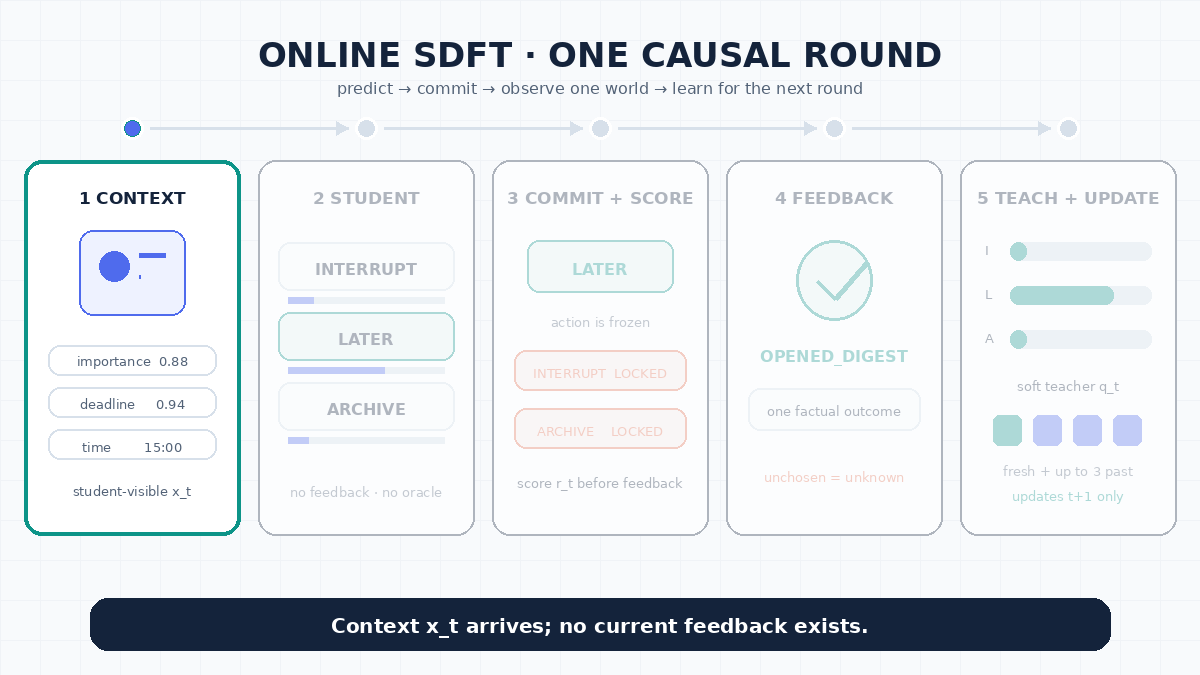

In [1]:
# @title Generate the in-memory Online-SDFT animation { display-mode: "form" }
from io import BytesIO
from PIL import Image as PILImage, ImageDraw, ImageFont
from matplotlib import font_manager
import matplotlib.pyplot as plt

GIF_WIDTH, GIF_HEIGHT = 1200, 675
PALETTE = {
    "bg": "#F8FAFC",
    "navy": "#14233B",
    "blue": "#4F6BED",
    "teal": "#0D9488",
    "coral": "#E76F51",
    "slate": "#526277",
    "line": "#D7E0EA",
    "pale_blue": "#EEF2FF",
    "pale_teal": "#E7F6F3",
    "pale_coral": "#FCEEEA",
    "white": "#FFFFFF",
}


def _font(size, bold=False):
    weight = "bold" if bold else "normal"
    path = font_manager.findfont(
        font_manager.FontProperties(family="DejaVu Sans", weight=weight)
    )
    return ImageFont.truetype(path, size=size)


FONTS = {
    "title": _font(34, True),
    "heading": _font(17, True),
    "body": _font(16),
    "body_bold": _font(16, True),
    "small": _font(13),
    "status": _font(20, True),
}


def _rgb(hex_color):
    value = hex_color.lstrip("#")
    return tuple(int(value[i:i + 2], 16) for i in (0, 2, 4))


def _blend(foreground, background, alpha):
    fg, bg = _rgb(foreground), _rgb(background)
    return tuple(round(alpha * f + (1 - alpha) * b) for f, b in zip(fg, bg))


def _center(draw, xy, text, font, fill):
    box = draw.textbbox((0, 0), text, font=font)
    width = box[2] - box[0]
    height = box[3] - box[1]
    draw.text((xy[0] - width / 2, xy[1] - height / 2), text, font=font, fill=fill)


def _arrow(draw, start, end, fill, width=4):
    draw.line((start, end), fill=fill, width=width)
    x, y = end
    direction = 1 if end[0] >= start[0] else -1
    draw.polygon(
        [(x, y), (x - 12 * direction, y - 7), (x - 12 * direction, y + 7)],
        fill=fill,
    )


def _pill(draw, box, text, fill, outline, text_fill, font=None):
    font = font or FONTS["body_bold"]
    draw.rounded_rectangle(box, radius=12, fill=fill, outline=outline, width=2)
    _center(draw, ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2), text, font, text_fill)


def _card(draw, box, title, intensity, active=False):
    outline = PALETTE["teal"] if active else _blend(PALETTE["navy"], PALETTE["bg"], intensity)
    fill = _blend(PALETTE["white"], PALETTE["bg"], max(0.55, intensity))
    draw.rounded_rectangle(box, radius=18, fill=fill, outline=outline, width=4 if active else 2)
    _center(draw, ((box[0] + box[2]) / 2, box[1] + 34), title,
            FONTS["heading"], _blend(PALETTE["navy"], PALETTE["bg"], intensity))


def _draw_context(draw, box, intensity):
    color = _blend(PALETTE["blue"], PALETTE["bg"], intensity)
    x1, y1, x2, _ = box
    draw.rounded_rectangle((x1 + 55, y1 + 70, x2 - 55, y1 + 155), radius=14,
                           fill=_blend(PALETTE["pale_blue"], PALETTE["bg"], intensity),
                           outline=color, width=2)
    draw.ellipse((x1 + 75, y1 + 91, x1 + 105, y1 + 121), fill=color)
    draw.line((x1 + 115, y1 + 95, x2 - 75, y1 + 95), fill=color, width=5)
    draw.line((x1 + 115, y1 + 116, x2 - 100, y1 + 116), fill=color, width=4)
    labels = ["importance  0.88", "deadline     0.94", "time        15:00"]
    for index, label in enumerate(labels):
        y = y1 + 185 + index * 42
        _pill(draw, (x1 + 24, y, x2 - 24, y + 30), label,
              _blend(PALETTE["white"], PALETTE["bg"], intensity),
              _blend(PALETTE["line"], PALETTE["bg"], intensity),
              _blend(PALETTE["slate"], PALETTE["bg"], intensity), FONTS["small"])
    _center(draw, ((x1 + x2) / 2, y1 + 330), "student-visible x_t",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))


def _draw_student(draw, box, intensity):
    x1, y1, x2, _ = box
    labels = [("INTERRUPT", 0.18), ("LATER", 0.67), ("ARCHIVE", 0.15)]
    for index, (label, probability) in enumerate(labels):
        y = y1 + 82 + index * 70
        selected = label == "LATER"
        fill = PALETTE["pale_teal"] if selected else PALETTE["white"]
        outline = PALETTE["teal"] if selected else PALETTE["line"]
        _pill(draw, (x1 + 20, y, x2 - 20, y + 48), label,
              _blend(fill, PALETTE["bg"], intensity),
              _blend(outline, PALETTE["bg"], intensity),
              _blend(PALETTE["navy"], PALETTE["bg"], intensity))
        draw.rectangle((x1 + 30, y + 55, x1 + 30 + 145 * probability, y + 61),
                       fill=_blend(PALETTE["blue"], PALETTE["bg"], intensity))
        draw.rectangle((x1 + 30 + 145 * probability, y + 55, x2 - 30, y + 61),
                       fill=_blend(PALETTE["line"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 330), "no feedback · no oracle",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))


def _draw_commit(draw, box, intensity):
    x1, y1, x2, _ = box
    _pill(draw, (x1 + 35, y1 + 80, x2 - 35, y1 + 132), "LATER",
          _blend(PALETTE["pale_teal"], PALETTE["bg"], intensity),
          _blend(PALETTE["teal"], PALETTE["bg"], intensity),
          _blend(PALETTE["teal"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 160), "action is frozen",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))
    for index, label in enumerate(("INTERRUPT  LOCKED", "ARCHIVE    LOCKED")):
        y = y1 + 190 + index * 58
        _pill(draw, (x1 + 22, y, x2 - 22, y + 40), label,
              _blend(PALETTE["pale_coral"], PALETTE["bg"], intensity),
              _blend(PALETTE["coral"], PALETTE["bg"], intensity),
              _blend(PALETTE["coral"], PALETTE["bg"], intensity), FONTS["small"])
    _center(draw, ((x1 + x2) / 2, y1 + 322), "score r_t before feedback",
            FONTS["small"], _blend(PALETTE["navy"], PALETTE["bg"], intensity))


def _draw_feedback(draw, box, intensity):
    x1, y1, x2, _ = box
    teal = _blend(PALETTE["teal"], PALETTE["bg"], intensity)
    draw.ellipse((x1 + 70, y1 + 80, x2 - 70, y1 + 160),
                 fill=_blend(PALETTE["pale_teal"], PALETTE["bg"], intensity),
                 outline=teal, width=3)
    draw.line((x1 + 91, y1 + 121, x1 + 109, y1 + 139), fill=teal, width=5)
    draw.line((x1 + 109, y1 + 139, x1 + 141, y1 + 102), fill=teal, width=5)
    _center(draw, ((x1 + x2) / 2, y1 + 195), "OPENED_DIGEST",
            FONTS["body_bold"], teal)
    _pill(draw, (x1 + 22, y1 + 228, x2 - 22, y1 + 270), "one factual outcome",
          _blend(PALETTE["white"], PALETTE["bg"], intensity),
          _blend(PALETTE["line"], PALETTE["bg"], intensity),
          _blend(PALETTE["navy"], PALETTE["bg"], intensity), FONTS["small"])
    _center(draw, ((x1 + x2) / 2, y1 + 315), "unchosen = unknown",
            FONTS["small"], _blend(PALETTE["coral"], PALETTE["bg"], intensity))


def _draw_teacher(draw, box, intensity):
    x1, y1, x2, _ = box
    values = [("I", 0.12), ("L", 0.76), ("A", 0.12)]
    for index, (label, value) in enumerate(values):
        y = y1 + 82 + index * 44
        draw.text((x1 + 25, y), label, font=FONTS["small"],
                  fill=_blend(PALETTE["navy"], PALETTE["bg"], intensity))
        draw.rounded_rectangle((x1 + 50, y, x2 - 25, y + 18), radius=8,
                               fill=_blend(PALETTE["line"], PALETTE["bg"], intensity))
        draw.rounded_rectangle((x1 + 50, y, x1 + 50 + 135 * value, y + 18), radius=8,
                               fill=_blend(PALETTE["teal"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 225), "soft teacher q_t",
            FONTS["small"], _blend(PALETTE["navy"], PALETTE["bg"], intensity))
    for index in range(4):
        left = x1 + 33 + index * 40
        fill = PALETTE["teal"] if index == 0 else PALETTE["blue"]
        draw.rounded_rectangle((left, y1 + 255, left + 28, y1 + 285), radius=6,
                               fill=_blend(fill, PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 310), "fresh + up to 3 past",
            FONTS["small"], _blend(PALETTE["slate"], PALETTE["bg"], intensity))
    _center(draw, ((x1 + x2) / 2, y1 + 335), "updates t+1 only",
            FONTS["small"], _blend(PALETTE["teal"], PALETTE["bg"], intensity))


def _draw_frame(progress):
    image = PILImage.new("RGB", (GIF_WIDTH, GIF_HEIGHT), PALETTE["bg"])
    draw = ImageDraw.Draw(image)

    for x in range(0, GIF_WIDTH, 40):
        draw.line((x, 0, x, GIF_HEIGHT), fill="#F0F3F7", width=1)
    for y in range(0, GIF_HEIGHT, 40):
        draw.line((0, y, GIF_WIDTH, y), fill="#F0F3F7", width=1)

    _center(draw, (GIF_WIDTH / 2, 48), "ONLINE SDFT · ONE CAUSAL ROUND",
            FONTS["title"], PALETTE["navy"])
    _center(draw, (GIF_WIDTH / 2, 87), "predict → commit → observe one world → learn for the next round",
            FONTS["body"], PALETTE["slate"])

    left, gap, card_width = 24, 18, 216
    cards = [(left + index * (card_width + gap), 160,
              left + index * (card_width + gap) + card_width, 535)
             for index in range(5)]
    centers = [((box[0] + box[2]) / 2, 128) for box in cards]
    for index in range(4):
        _arrow(draw, (centers[index][0] + 18, 128),
               (centers[index + 1][0] - 18, 128), PALETTE["line"], 3)

    current = min(4, int(progress))
    for index, (cx, cy) in enumerate(centers):
        fill = PALETTE["teal"] if index <= current else PALETTE["line"]
        draw.ellipse((cx - 11, cy - 11, cx + 11, cy + 11), fill=fill,
                     outline=PALETTE["white"], width=3)

    if progress < 4:
        start = centers[int(progress)][0]
        finish = centers[int(progress) + 1][0]
        fraction = progress - int(progress)
        dot_x = start + (finish - start) * fraction
    else:
        dot_x = centers[-1][0]
    draw.ellipse((dot_x - 7, 121, dot_x + 7, 135), fill=PALETTE["blue"])

    titles = ("1 CONTEXT", "2 STUDENT", "3 COMMIT + SCORE",
              "4 FEEDBACK", "5 TEACH + UPDATE")
    renderers = (_draw_context, _draw_student, _draw_commit, _draw_feedback, _draw_teacher)
    for index, box in enumerate(cards):
        if index < current:
            intensity = 0.78
        elif index == current:
            intensity = 1.0
        else:
            intensity = 0.32
        _card(draw, box, titles[index], intensity, active=index == current)
        renderers[index](draw, box, intensity)

    if current == 4:
        _center(draw, (GIF_WIDTH / 2, 551), "Updated policy faces the next context",
                FONTS["small"], PALETTE["teal"])
        _arrow(draw, (cards[4][2] - 15, 574), (cards[0][0] + 15, 574), PALETTE["teal"], 4)

    status = (
        "Context x_t arrives; no current feedback exists.",
        "The student samples its own action from π_t(.|x_t).",
        "The selected action and regret are frozen before feedback.",
        "Only the selected action produces factual feedback.",
        "The teacher's soft target updates a tiny batch for t+1.",
    )[current]
    draw.rounded_rectangle((90, 598, 1110, 650), radius=18,
                           fill=PALETTE["navy"], outline=PALETTE["navy"])
    _center(draw, (600, 624), status, FONTS["status"], PALETTE["white"])
    return image


def make_online_sdft_gif():
    frames = []
    for stage in range(5):
        for substep in range(7):
            progress = stage + substep / 7 if stage < 4 else 4
            frames.append(_draw_frame(progress))
        pause_progress = stage + 0.99 if stage < 4 else 4.0
        frames.extend([_draw_frame(pause_progress)] * 2)
    buffer = BytesIO()
    frames[0].save(buffer, format="GIF", save_all=True,
                   append_images=frames[1:], duration=135, loop=0,
                   optimize=True, disposal=2)
    return buffer.getvalue()

from IPython.display import Image as NotebookImage, Markdown, display
gif_bytes = make_online_sdft_gif()
display(NotebookImage(data=gif_bytes))

### 2.1 What the animation establishes

- The student acts without current feedback or privileged telemetry.
- The score is frozen before the user outcome exists.
- Only the selected route produces feedback; unchosen outcomes stay unknown.
- The teacher's soft distribution updates at most four records for `t+1`.

If the student chooses `ARCHIVE`, no notification exists. The only factual outcomes are an organic inbox open or no observation—never a push or digest click.

## 3. Understand the setting

### 3.1 Contextual-bandit contract

| Moment | Available | Sealed away |
| --- | --- | --- |
| Student rollout | current context, parameters, past factual records | current feedback, future events, scoring oracle |
| Environment | outcome caused by the selected action | outcomes for both unchosen actions |
| Online update | post-decision teacher target, batch ≤4 | oracle action, ground-truth demonstration, retroactive correction |

The evaluator can grade the frozen action from hidden simulator state, but neither student nor teacher receives its utility vector.

### 3.2 Why this is not batch learning

| Batch learning | This online stream |
| --- | --- |
| Labels exist before training | Feedback exists only after acting |
| Examples may be shuffled for many epochs | Events arrive once, in order |
| Evaluation follows training | Every live action is evaluated |
| Early errors disappear from test metrics | Cold-start and adaptation errors remain |

There is no train/test split. The stream drifts from weekday to on-call to off-hours behavior, and the objective is performance **during** adaptation.

## 4. Compare the methods

### 4.1 Five methods on the same stream

| Method | Online adaptation |
| --- | --- |
| Base | Frozen generic policy |
| ICL | Recent sampled teacher actions in context |
| RAG | Similar past sampled teacher actions retrieved |
| Online-SFT | Weight update from one sampled teacher action |
| **Online-SDFT** | Weight update from the teacher's full soft distribution |

All methods act with the same 6% exploration and never receive the evaluator's preferred action.

### 4.2 Online-SFT versus Online-SDFT

| | Online-SFT | Online-SDFT |
| --- | --- | --- |
| Student rollout | From `x_t`, without `z_t` | From `x_t`, without `z_t` |
| Teacher timing | After factual feedback | After factual feedback |
| Retained target | One sampled hard action | Full soft distribution `q_t` |
| Online batch | Fresh + up to 3 past items | Fresh + up to 3 past items |

Neither method trains on a ground-truth demonstration. SDFT preserves the teacher's relative preference over all routes instead of reducing it to one noisy draw.

## 5. Reproduce the experiment (optional)

The next three subsections contain the complete embedded implementation, execute 20 paired streams, and recompute the headline table. Skip to [Section 6](#6-inspect-the-metrics-optional) if you only want the saved outputs.

### 5.1 Load the embedded simulator and policies

This long cell defines the stream, factual feedback, scoring oracle, teacher, five methods, and online update loop. It reads no external file.

In [2]:
# @title Optional: embedded simulator and method implementation { display-mode: "form" }
from __future__ import annotations

import csv
import json
import math
import random
from collections import Counter, defaultdict
from dataclasses import dataclass

import numpy as np

ACTIONS = ("INTERRUPT", "LATER", "ARCHIVE")
METHODS = ("Base", "ICL", "RAG", "Online-SFT", "Online-SDFT")
CATEGORIES = ("manager", "calendar", "monitoring", "teammate", "social", "receipt", "promo")
REGIMES = ("weekday", "on-call", "off-hours")
PHASE_LENGTH = 80
STREAM_LENGTH = PHASE_LENGTH * len(REGIMES)
FEATURE_DIM = len(CATEGORIES) + 8
EXPLORATION_EPSILON = 0.06
REPLAY_SIZE = 24
SFT_LR = 0.05
SDFT_LR = 0.50
TEACHER_TEMPERATURE = 0.95


def softmax(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    x = logits / temperature
    x = x - np.max(x)
    p = np.exp(x)
    return p / p.sum()


def one_hot(index: int, n: int) -> np.ndarray:
    out = np.zeros(n)
    out[index] = 1.0
    return out


@dataclass
class Event:
    event_id: str
    phase: int
    category: str
    hour: float
    importance: float
    deadline: float
    affinity: float
    busy: float
    x: np.ndarray
    # Privileged post-decision telemetry. Not part of student context x.
    z: dict


def category_profile(category: str) -> tuple[float, float, float]:
    """Base (importance, deadline pressure, personal affinity)."""
    return {
        "manager": (0.82, 0.72, 0.55),
        "calendar": (0.88, 0.94, 0.45),
        "monitoring": (0.78, 0.83, 0.25),
        "teammate": (0.45, 0.28, 0.58),
        "social": (0.25, 0.10, 0.78),
        "receipt": (0.35, 0.16, 0.38),
        "promo": (0.10, 0.04, 0.18),
    }[category]


def make_event(rng: np.random.Generator, phase: int, index: int, prefix: str) -> Event:
    # Balanced categories prevent trivial majority-class wins.
    category = CATEGORIES[index % len(CATEGORIES)]
    base_imp, base_deadline, base_affinity = category_profile(category)
    hour_centres = (11.0, 15.0, 20.5)
    hour = float(np.clip(rng.normal(hour_centres[phase], 1.8), 0, 23.9))
    importance = float(np.clip(rng.normal(base_imp, 0.11), 0, 1))
    deadline = float(np.clip(rng.normal(base_deadline, 0.12), 0, 1))
    affinity = float(np.clip(rng.normal(base_affinity, 0.12), 0, 1))
    # Current interruptibility is measurable only after the decision window.
    busy_mean = (0.68, 0.36, 0.18)[phase]
    busy = float(np.clip(rng.normal(busy_mean, 0.18), 0, 1))
    incident_on_call = float(phase == 1 and category == "monitoring")
    leisure_social = float(phase == 2 and category == "social")
    manager_focus = float(phase == 0 and category == "manager")

    cat = one_hot(CATEGORIES.index(category), len(CATEGORIES))
    x = np.concatenate([
        cat,
        np.array([
            importance,
            deadline,
            affinity,
            math.sin(2 * math.pi * hour / 24),
            math.cos(2 * math.pi * hour / 24),
            phase / 2.0,                 # coarse time-of-week, available on device
            1.0,
            importance * deadline,
        ]),
    ])
    z = {
        "busy": busy,
        "incident_on_call": incident_on_call,
        "leisure_social": leisure_social,
        "manager_focus": manager_focus,
    }
    return Event(f"{prefix}-{index:04d}", phase, category, hour, importance,
                 deadline, affinity, busy, x, z)


def make_stream(seed: int) -> list[Event]:
    rng = np.random.default_rng(seed)
    events = []
    for phase in range(3):
        phase_events = [make_event(rng, phase, i, f"s{seed}-p{phase}")
                        for i in range(PHASE_LENGTH)]
        rng.shuffle(phase_events)
        events.extend(phase_events)
    return events


def oracle_utilities(event: Event) -> np.ndarray:
    """Simulator-only expected utilities; inaccessible to learning algorithms."""
    z = event.z
    urgency = event.importance * event.deadline
    interrupt = (1.45 * urgency + 0.42 * event.affinity - 1.20 * z["busy"]
                 + 1.00 * z["incident_on_call"] + 0.60 * z["manager_focus"]
                 + 0.50 * z["leisure_social"])
    later = (0.72 * event.importance + 0.58 * event.affinity - 0.62 * urgency
             + 0.22 * z["busy"] - 0.62 * z["incident_on_call"])
    archive = (0.72 * (1 - event.importance) + 0.36 * (1 - event.affinity)
               - 0.80 * urgency - 0.50 * z["leisure_social"])
    return np.array([interrupt, later, archive])


def factual_feedback(event: Event, action: int, rng: np.random.Generator) -> dict:
    """Execute one action. No potential outcome is sampled for another action."""
    utility = oracle_utilities(event)[action]
    engage_p = float(np.clip(0.36 + 0.24 * utility, 0.04, 0.92))
    draw = float(rng.random())
    if action == 0:
        outcome = "OPENED_PUSH" if draw < engage_p else (
            "DISMISSED_PUSH" if draw < engage_p + 0.45 else "IGNORED_PUSH")
        reward = {"OPENED_PUSH": 0.72, "DISMISSED_PUSH": -0.58,
                  "IGNORED_PUSH": -0.78}[outcome] - 0.30 * event.busy
        channel, delay = "push_delivered", 0
    elif action == 1:
        outcome = "OPENED_DIGEST" if draw < engage_p else "IGNORED_DIGEST"
        reward = {"OPENED_DIGEST": 0.48, "IGNORED_DIGEST": -0.16}[outcome]
        reward -= 0.28 * event.importance * event.deadline
        channel, delay = "digest_delivered", 90
    else:
        organic_p = float(np.clip(0.08 + 0.15 * event.affinity, 0.04, 0.30))
        outcome = "ORGANIC_INBOX_OPEN" if draw < organic_p else "NO_OBSERVATION"
        reward = 0.16 if outcome == "ORGANIC_INBOX_OPEN" else 0.0
        channel, delay = "no_notification_sent", 240
    return {"action_taken": ACTIONS[action], "channel": channel, "outcome": outcome,
            "delay_minutes": delay, "reward": round(float(reward), 4)}


def teacher_policy(event: Event, action: int, feedback: dict,
                   rng: np.random.Generator) -> np.ndarray:
    """Privileged teacher rollout π(.|x,z), never a ground-truth action.

    The teacher has noisy access to post-decision device state and semantic
    metadata. Its scores approximate user utility but are deliberately noisy and
    calibrated. The factual reward tilts only the action that was actually taken.
    """
    z = event.z
    urgency = event.importance * event.deadline
    scores = np.array([
        1.30 * urgency + 0.38 * event.affinity - 1.05 * z["busy"]
        + 0.88 * z["incident_on_call"] + 0.48 * z["manager_focus"]
        + 0.42 * z["leisure_social"],
        0.66 * event.importance + 0.52 * event.affinity - 0.55 * urgency
        + 0.18 * z["busy"] - 0.48 * z["incident_on_call"],
        0.65 * (1 - event.importance) + 0.31 * (1 - event.affinity)
        - 0.68 * urgency - 0.40 * z["leisure_social"],
    ])
    scores += rng.normal(0, 0.13, len(ACTIONS))
    scores[action] += 0.48 * float(feedback["reward"])
    return softmax(scores, temperature=TEACHER_TEMPERATURE)


class LinearPolicy:
    def __init__(self, initial: np.ndarray, lr: float = 0.075):
        self.w = initial.copy()
        self.lr = lr

    def probs(self, x: np.ndarray) -> np.ndarray:
        return softmax(self.w @ x)

    def update(self, batch: list[tuple[np.ndarray, np.ndarray]]) -> None:
        grad = np.zeros_like(self.w)
        for x, target in batch:
            p = self.probs(x)
            grad += np.outer(p - target, x)
        self.w -= self.lr * grad / len(batch)


def initial_policy(seed: int) -> np.ndarray:
    """A weak generic notification prior shared identically by every method."""
    rng = np.random.default_rng(seed + 90_000)
    w = rng.normal(0, 0.025, (len(ACTIONS), FEATURE_DIM))
    # Generic systems over-interrupt important/deadline items and archive promos.
    w[0, len(CATEGORIES) + 0] = 0.55
    w[0, len(CATEGORIES) + 1] = 0.42
    w[1, len(CATEGORIES) + 2] = 0.30
    w[2, CATEGORIES.index("promo")] = 0.65
    w[2, len(CATEGORIES) + 0] = -0.28
    return w


def method_probs(method: str, policy: LinearPolicy, x: np.ndarray,
                 memory: list[dict]) -> np.ndarray:
    base = policy.probs(x)
    if method in {"Base", "Online-SFT", "Online-SDFT"} or not memory:
        return base
    if method == "ICL":
        rows = memory[-12:]
        vote = np.full(len(ACTIONS), 0.25)
        for row in rows:
            vote[row["teacher_action"]] += 1
        vote /= vote.sum()
        return 0.40 * base + 0.60 * vote
    # RAG: hard teacher rollouts from semantically closest past notifications.
    norms = [(float(np.dot(x, row["x"]) /
                    (np.linalg.norm(x) * np.linalg.norm(row["x"]) + 1e-9)), row)
             for row in memory]
    rows = [row for _, row in sorted(norms, key=lambda pair: pair[0], reverse=True)[:5]]
    vote = np.full(len(ACTIONS), 0.20)
    for row in rows:
        vote[row["teacher_action"]] += 1
    vote /= vote.sum()
    return 0.28 * base + 0.72 * vote


def run_method(seed: int, method: str, stream: list[Event], rollout_writer,
               curve_writer) -> dict:
    rng = np.random.default_rng(seed * 100 + METHODS.index(method) * 13 + 5)
    # Separate coarse sweeps selected stable online-learning rates for the soft
    # and hard targets. SDFT supports the larger step because q is low variance.
    lr = SDFT_LR if method == "Online-SDFT" else (SFT_LR if method == "Online-SFT" else 0.055)
    policy = LinearPolicy(initial_policy(seed), lr=lr)
    memory: list[dict] = []
    replay: list[tuple[np.ndarray, np.ndarray]] = []
    cum_regret = 0.0
    cum_correct = 0
    phase_correct = Counter()
    phase_total = Counter()
    phase_regret = Counter()

    for t, event in enumerate(stream, start=1):
        probs = method_probs(method, policy, event.x, memory)
        greedy = one_hot(int(np.argmax(probs)), len(ACTIONS))
        behavior = ((1 - EXPLORATION_EPSILON) * greedy
                    + EXPLORATION_EPSILON / len(ACTIONS))
        action = int(rng.choice(len(ACTIONS), p=behavior))
        # Prequential score: freeze and score the action before feedback exists.
        utilities = oracle_utilities(event)
        oracle = int(np.argmax(utilities))
        step_regret = float(utilities[oracle] - utilities[action])
        correct = int(action == oracle)
        cum_regret += step_regret
        cum_correct += correct
        phase_correct[event.phase] += correct
        phase_total[event.phase] += 1
        phase_regret[event.phase] += step_regret

        # Only now execute the chosen route and obtain z for future learning.
        feedback = factual_feedback(event, action, rng)
        teacher_probs = teacher_policy(event, action, feedback, rng)
        teacher_action = int(rng.choice(len(ACTIONS), p=teacher_probs))

        record = {"seed": seed, "method": method, "t": t,
                  "event_id": event.event_id, "phase": event.phase,
                  "regime": REGIMES[event.phase], "category": event.category,
                  "student_probs": dict(zip(ACTIONS, map(float, probs))),
                  "action": ACTIONS[action], "feedback": feedback,
                  "teacher_probs": dict(zip(ACTIONS, map(float, teacher_probs))),
                  "teacher_rollout": ACTIONS[teacher_action],
                  "oracle_action_scoring_only": ACTIONS[oracle],
                  "correct_online": correct, "step_regret": step_regret,
                  "cum_regret": cum_regret, "cum_accuracy": cum_correct / t}
        rollout_writer.write(json.dumps(record) + "\n")
        memory.append({"x": event.x.copy(), "teacher_action": teacher_action,
                       "feedback": feedback})

        if method == "Online-SFT":
            target = one_hot(teacher_action, len(ACTIONS))
            replay.append((event.x.copy(), target))
        elif method == "Online-SDFT":
            replay.append((event.x.copy(), teacher_probs.copy()))
        if method in {"Online-SFT", "Online-SDFT"}:
            replay = replay[-REPLAY_SIZE:]
            # Small online batch: fresh item plus up to three recent rollouts.
            indices = [len(replay) - 1]
            if len(replay) > 1:
                indices += rng.choice(len(replay) - 1,
                                      size=min(3, len(replay) - 1), replace=False).tolist()
            policy.update([replay[i] for i in indices])

        curve_writer.writerow({"seed": seed, "method": method, "t": t,
                               "phase": event.phase, "regime": REGIMES[event.phase],
                               "step_correct": correct, "step_regret": step_regret,
                               "cum_accuracy": cum_correct / t,
                               "cum_regret": cum_regret})

    return {"seed": seed, "method": method,
            "online_accuracy": cum_correct / len(stream),
            "cum_regret": cum_regret,
            "regret_per_decision": cum_regret / len(stream),
            **{f"online_accuracy_{REGIMES[p]}": phase_correct[p] / phase_total[p]
               for p in range(3)},
            **{f"regret_{REGIMES[p]}": phase_regret[p] for p in range(3)}}


def mean_ci(values: list[float]) -> dict:
    a = np.asarray(values, dtype=float)
    return {"mean": float(a.mean()), "std": float(a.std(ddof=1)),
            "ci95": float(1.96 * a.std(ddof=1) / math.sqrt(len(a)))}


### 5.2 Run the paired streams

All artifacts remain in memory: 20 seeds × 5 methods × 240 online decisions.

In [3]:
# @title Run the complete paired experiment in memory { display-mode: "form" }
from io import StringIO


def run_experiment_in_memory(seeds=20):
    curve_fields = ["seed", "method", "t", "phase", "regime", "step_correct",
                    "step_regret", "cum_accuracy", "cum_regret"]
    metrics, rollouts, curves = [], [], []

    for seed in range(seeds):
        stream = make_stream(seed)
        for method in METHODS:
            rollout_buffer = StringIO()
            curve_buffer = StringIO()
            curve_writer = csv.DictWriter(curve_buffer, fieldnames=curve_fields,
                                          lineterminator="\n")
            curve_writer.writeheader()
            metrics.append(run_method(seed, method, stream,
                                      rollout_buffer, curve_writer))
            rollout_buffer.seek(0)
            rollouts.extend(json.loads(line) for line in rollout_buffer)
            curve_buffer.seek(0)
            curves.extend(csv.DictReader(curve_buffer))

    metric_names = [key for key in metrics[0] if key not in {"seed", "method"}]
    summary = {}
    for method in METHODS:
        rows = [row for row in metrics if row["method"] == method]
        summary[method] = {
            metric: mean_ci([float(row[metric]) for row in rows])
            for metric in metric_names
        }

    grouped = defaultdict(dict)
    for row in rollouts:
        grouped[(row["seed"], row["t"])][row["method"]] = row
    qualitative = []
    for (seed, t), rows in sorted(grouped.items()):
        if len(rows) != len(METHODS) or t <= PHASE_LENGTH:
            continue
        oracle = rows["Online-SDFT"]["oracle_action_scoring_only"]
        if (rows["Online-SDFT"]["action"] == oracle
                and all(rows[name]["action"] != oracle
                        for name in METHODS if name != "Online-SDFT")):
            qualitative.append({"seed": seed, "t": t, "oracle": oracle,
                                "regime": rows["Online-SDFT"]["regime"],
                                "category": rows["Online-SDFT"]["category"],
                                "methods": rows})
        if len(qualitative) == 8:
            break
    return metrics, rollouts, curves, summary, qualitative


N_SEEDS = 20
metrics, rollouts, curves, summary, qualitative = run_experiment_in_memory(N_SEEDS)
print(f"Finished {N_SEEDS} paired streams × {len(METHODS)} methods × {STREAM_LENGTH} decisions")

Finished 20 paired streams × 5 methods × 240 decisions


### 5.3 Confirm the recomputed metrics

In [4]:
# @title Display the recomputed result table { display-mode: "form" }
from IPython.display import Markdown, display

header = "| Method | Online accuracy | 95% CI | Cumulative regret | 95% CI |\n| --- | ---: | ---: | ---: | ---: |"
rows = []
for method in METHODS:
    accuracy = summary[method]["online_accuracy"]
    regret = summary[method]["cum_regret"]
    rows.append(
        f"| {method} | {100 * accuracy['mean']:.2f}% | ±{100 * accuracy['ci95']:.2f} | "
        f"{regret['mean']:.2f} | ±{regret['ci95']:.2f} |"
    )
display(Markdown(header + "\n" + "\n".join(rows)))

| Method | Online accuracy | 95% CI | Cumulative regret | 95% CI |
| --- | ---: | ---: | ---: | ---: |
| Base | 52.17% | ±1.23 | 71.17 | ±2.93 |
| ICL | 45.75% | ±1.05 | 78.38 | ±3.39 |
| RAG | 53.15% | ±1.62 | 56.60 | ±4.39 |
| Online-SFT | 61.79% | ±2.51 | 40.17 | ±4.51 |
| Online-SDFT | 74.77% | ±1.24 | 18.65 | ±1.28 |

## 6. Inspect the metrics (optional)

### 6.1 Aggregate online accuracy and regret

Accuracy is binary; regret weights mistakes by the evaluator's hidden utility gap. Both include cold start and exploration.

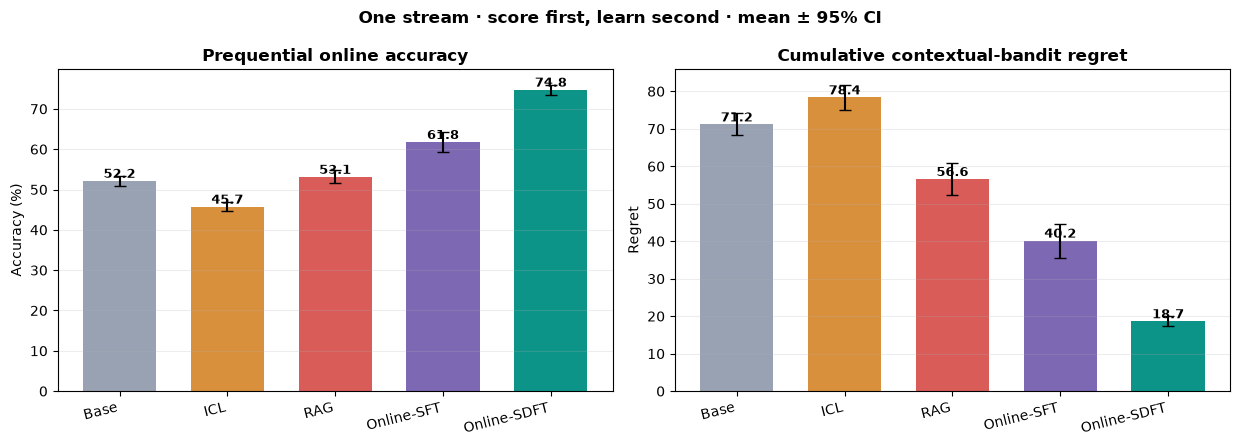

In [5]:
# @title Plot aggregate accuracy and cumulative regret { display-mode: "form" }
import matplotlib.pyplot as plt

colors = {"Base": "#98A2B3", "ICL": "#D9903D", "RAG": "#D95C59",
          "Online-SFT": "#7D68B3", "Online-SDFT": "#0D9488"}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
x_positions = np.arange(len(METHODS))
accuracy = [100 * summary[name]["online_accuracy"]["mean"] for name in METHODS]
accuracy_ci = [100 * summary[name]["online_accuracy"]["ci95"] for name in METHODS]
regret = [summary[name]["cum_regret"]["mean"] for name in METHODS]
regret_ci = [summary[name]["cum_regret"]["ci95"] for name in METHODS]

for ax, values, errors, title, ylabel in (
    (axes[0], accuracy, accuracy_ci, "Prequential online accuracy", "Accuracy (%)"),
    (axes[1], regret, regret_ci, "Cumulative contextual-bandit regret", "Regret"),
):
    bars = ax.bar(x_positions, values, yerr=errors, capsize=4,
                  color=[colors[name] for name in METHODS], width=0.68)
    ax.set_xticks(x_positions, METHODS, rotation=14, ha="right")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.22)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
fig.suptitle("One stream · score first, learn second · mean ± 95% CI", fontweight="bold")
fig.tight_layout()
plt.show()

### 6.2 Learning along the stream

Dashed boundaries mark weekday → on-call → off-hours drift. Nothing is filtered or rescored after learning.

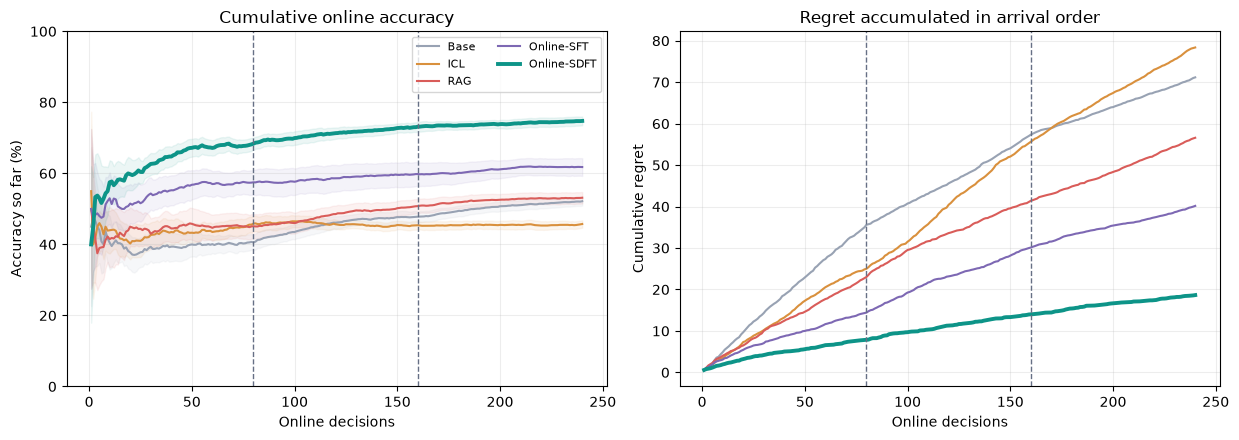

In [6]:
# @title Plot online learning curves { display-mode: "form" }
import matplotlib.pyplot as plt

colors = {"Base": "#98A2B3", "ICL": "#D9903D", "RAG": "#D95C59",
          "Online-SFT": "#7D68B3", "Online-SDFT": "#0D9488"}

by_accuracy, by_regret = defaultdict(list), defaultdict(list)
for row in curves:
    key = (row["method"], int(row["t"]))
    by_accuracy[key].append(float(row["cum_accuracy"]))
    by_regret[key].append(float(row["cum_regret"]))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for method in METHODS:
    ts = sorted(t for name, t in by_accuracy if name == method)
    acc = np.array([by_accuracy[(method, t)] for t in ts])
    mean_acc = np.array([values.mean() for values in acc]) * 100
    ci_acc = np.array([1.96 * values.std(ddof=1) / np.sqrt(len(values)) for values in acc]) * 100
    mean_regret = [np.mean(by_regret[(method, t)]) for t in ts]
    width = 2.8 if method == "Online-SDFT" else 1.5
    axes[0].plot(ts, mean_acc, color=colors[method], label=method, lw=width)
    axes[0].fill_between(ts, mean_acc - ci_acc, mean_acc + ci_acc,
                         color=colors[method], alpha=0.08)
    axes[1].plot(ts, mean_regret, color=colors[method], label=method, lw=width)

for ax in axes:
    for boundary in (PHASE_LENGTH, 2 * PHASE_LENGTH):
        ax.axvline(boundary, color="#667085", ls="--", lw=1)
    ax.grid(alpha=0.22)
    ax.set_xlabel("Online decisions")
axes[0].set(title="Cumulative online accuracy", ylabel="Accuracy so far (%)", ylim=(0, 100))
axes[1].set(title="Regret accumulated in arrival order", ylabel="Cumulative regret")
axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 7. Audit the realism (optional)

### 7.1 Counterfactual boundary

This assertion verifies that archived actions never produce notification clicks.

In [7]:
# @title Assert the ARCHIVE feedback invariant { display-mode: "form" }
from IPython.display import Markdown, display

archive_rows = [row for row in rollouts if row["action"] == "ARCHIVE"]
archive_outcomes = Counter(row["feedback"]["outcome"] for row in archive_rows)
assert set(archive_outcomes) <= {"ORGANIC_INBOX_OPEN", "NO_OBSERVATION"}
assert all("oracle_action_scoring_only" in row for row in rollouts)

display(Markdown(
    f"**{len(archive_rows):,} archived decisions** produced only factual outcomes: "
    f"`{dict(archive_outcomes)}`. No archived decision generated a push or digest click."
))

**5,142 archived decisions** produced only factual outcomes: `{'NO_OBSERVATION': 4536, 'ORGANIC_INBOX_OPEN': 606}`. No archived decision generated a push or digest click.

### 7.2 Actions actually executed

The action mix is a diagnostic, not a relabeled counterfactual dataset.

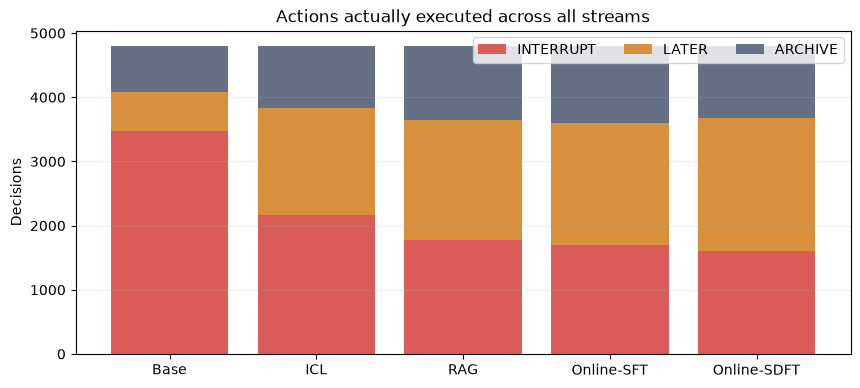

In [8]:
# @title Plot executed action counts { display-mode: "form" }
import matplotlib.pyplot as plt

counts = {method: Counter(row["action"] for row in rollouts if row["method"] == method)
          for method in METHODS}
fig, ax = plt.subplots(figsize=(10, 4.2))
bottom = np.zeros(len(METHODS))
action_colors = {"INTERRUPT": "#D95C59", "LATER": "#D9903D", "ARCHIVE": "#667085"}
for action in ACTIONS:
    values = np.array([counts[method][action] for method in METHODS])
    ax.bar(METHODS, values, bottom=bottom, label=action, color=action_colors[action])
    bottom += values
ax.set(title="Actions actually executed across all streams", ylabel="Decisions")
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.2)
plt.show()

## 8. Inspect later-stream examples (optional)

These examples are selected after all rollouts finish. They show later decisions where Online-SDFT's actual pre-feedback action matches the evaluator and every comparison arm does not.

In [9]:
# @title Show qualitative Online-SDFT wins { display-mode: "form" }
from IPython.display import Markdown, display

for example in qualitative[:4]:
    display(Markdown(
        f"### Step {example['t']} · {example['regime']} · {example['category']}  \n"
        f"Scoring-best route: **{example['oracle']}**"
    ))
    for method in METHODS:
        row = example["methods"][method]
        marker = "✅" if row["action"] == example["oracle"] else "·"
        print(f"{marker} {method:<13} {row['action']:<10} → {row['feedback']['outcome']}")

### Step 87 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → DISMISSED_PUSH
· ICL           LATER      → OPENED_DIGEST
· RAG           INTERRUPT  → DISMISSED_PUSH
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 96 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → OPENED_PUSH
· ICL           INTERRUPT  → OPENED_PUSH
· RAG           LATER      → IGNORED_DIGEST
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 150 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → IGNORED_PUSH
· ICL           INTERRUPT  → IGNORED_PUSH
· RAG           LATER      → OPENED_DIGEST
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 162 · off-hours · social  
Scoring-best route: **LATER**

· Base          INTERRUPT  → OPENED_PUSH
· ICL           INTERRUPT  → DISMISSED_PUSH
· RAG           INTERRUPT  → DISMISSED_PUSH
· Online-SFT    INTERRUPT  → OPENED_PUSH
✅ Online-SDFT   LATER      → IGNORED_DIGEST


## 9. Takeaway

This is not batch training followed by a clean test. Every method pays for cold-start, exploration, and adaptation errors as they happen. Online-SFT keeps one noisy teacher draw; Online-SDFT keeps the teacher's complete relative preference. On identical streams, that soft signal reaches **74.8% online accuracy and 18.7 cumulative regret**, versus **61.8% and 40.2** for Online-SFT.